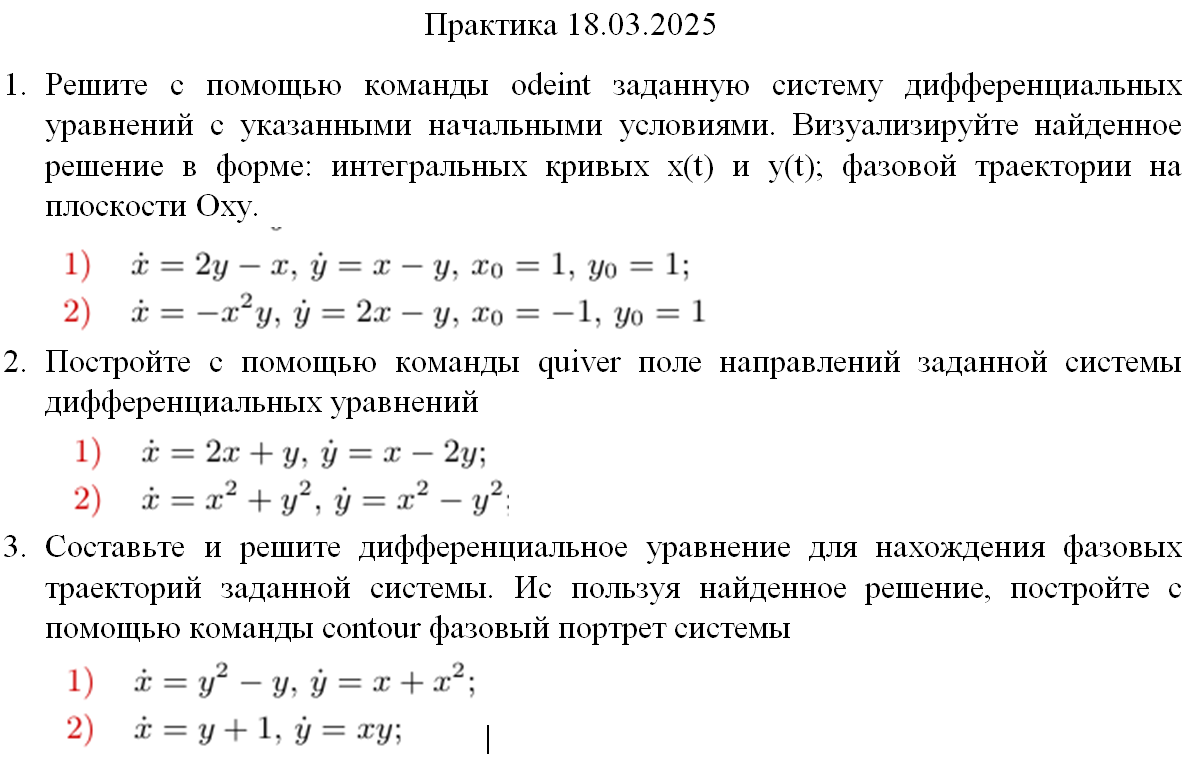

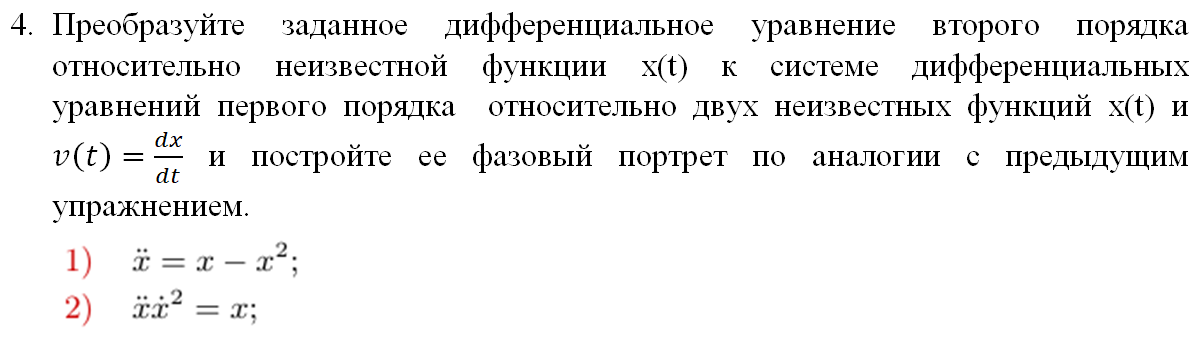

1.2) ẋ = 2y − x, ẏ = x − y. Суть задачи: Линейная система. Решается с помощью odeint. Классический пример фазового портрета.
1.2) ẋ = −x²y, ẏ = 2x − y. Суть задачи: Нелинейная система, тоже решается через odeint.

2.1)ẋ = 2x + y, ẏ = x − 2y. Суть задачи: Построение поля направлений (quiver). Линейная система.
2.2) ẋ = x² + y², ẏ = x² − y². Суть задачи: Построение поля направлений для нелинейной системы.

3.1) ẋ = y² − y, ẏ = x + x². Суть задачи: Составление уравнения фазовых траекторий, построение через contour. Нелинейная система.
3.2) ẋ = y + 1, ẏ = xy. Суть задачи: Аналогично, но с другим видом нелинейности.

4.1)ẍ = x − x². Суть задачи: Уравнение второго порядка. Требует преобразования к системе первого порядка и построения фазового портрета (через x, v).
4.2)ẍ·x² = x. Суть задачи: также уравнение второго порядка, но в другой форме.

Уникальными по своей сути и методу являются только: 1.1, 1.2, 3.1, 3.2, 4.1

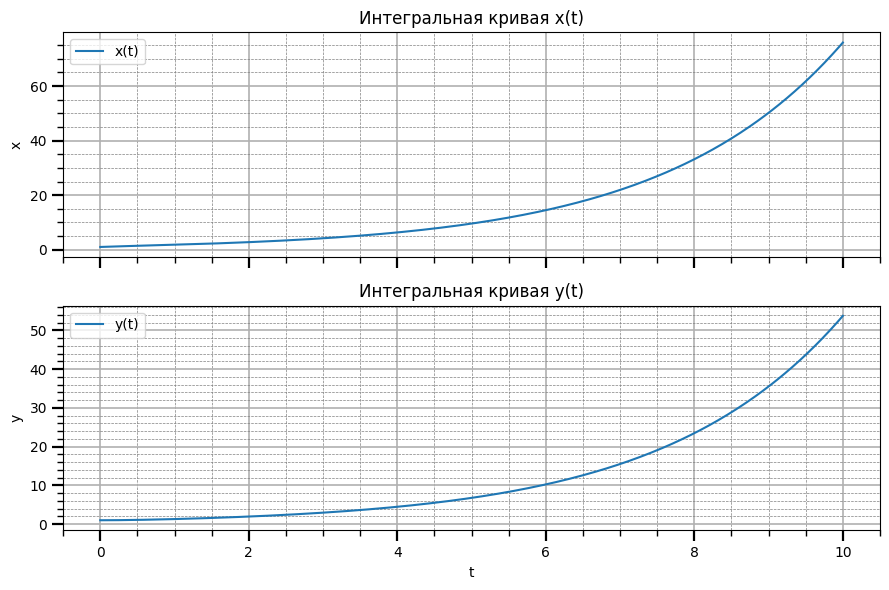

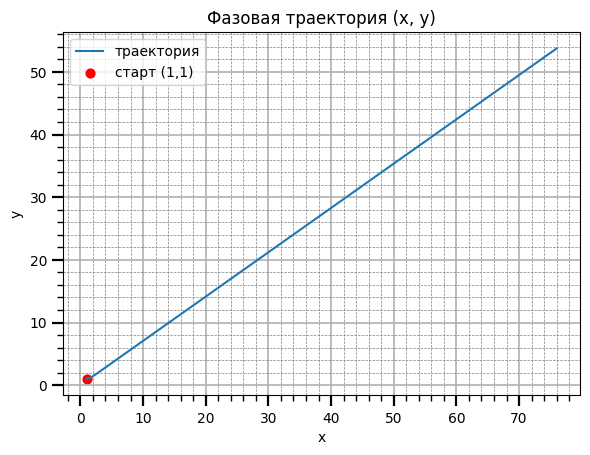

In [2]:
#1.1
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# система ẋ = 2y − x, ẏ = x − y
def f(u, t):
    x, y = u
    return [2*y - x, x - y]

# начальные условия и сетка времени
u0 = [1.0, 1.0]
t = np.linspace(0, 10, 400)

# численное решение
sol = odeint(f, u0, t)
x, y = sol[:, 0], sol[:, 1]

# интегральные кривые x(t), y(t)
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(t, x, label='x(t)')
ax[1].plot(t, y, label='y(t)')

for a, ttl in zip(ax, ['Интегральная кривая x(t)', 'Интегральная кривая y(t)']):
    a.set_title(ttl, fontsize=12)
    a.grid(which='major', linewidth=1.2)
    a.grid(which='minor', linestyle='--', color='gray', linewidth=0.5)
    a.xaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.set_minor_locator(AutoMinorLocator())
    a.tick_params(which='major', length=8, width=1.6)
    a.tick_params(which='minor', length=4, width=1)
    a.legend()

ax[1].set_xlabel('t')
ax[0].set_ylabel('x')
ax[1].set_ylabel('y')
plt.tight_layout()

# фазовая траектория на плоскости Oxy
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.plot(x, y, label='траектория')
ax2.scatter([u0[0]], [u0[1]], c='r', s=40, label='старт (1,1)')
ax2.set_title('Фазовая траектория (x, y)', fontsize=12)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(which='major', linewidth=1.2)
ax2.grid(which='minor', linestyle='--', color='gray', linewidth=0.5)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.tick_params(which='major', length=8, width=1.6)
ax2.tick_params(which='minor', length=4, width=1)
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
plt.tight_layout()
plt.show()


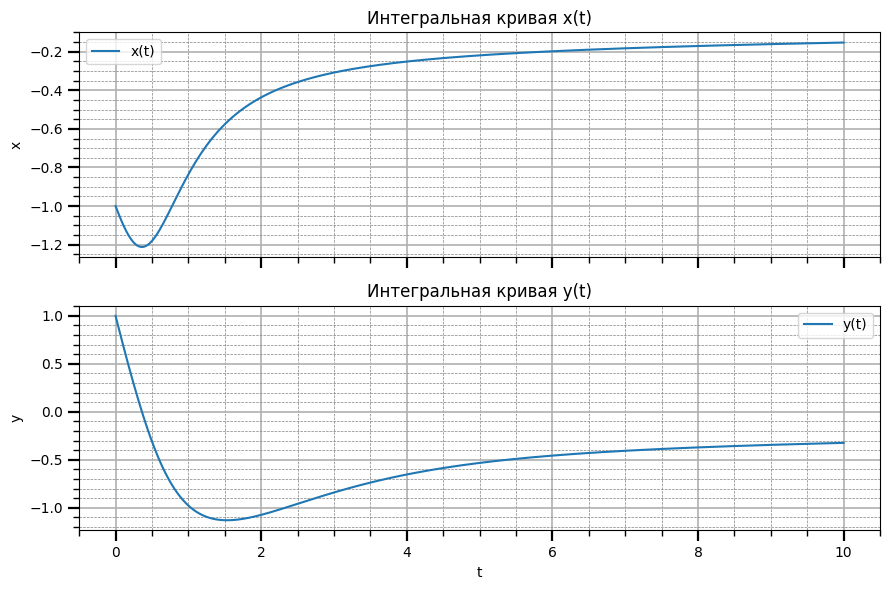

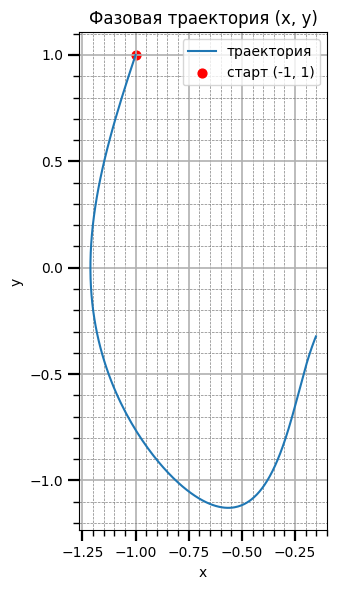

In [3]:
#1.2
def f(u, t):
    x, y = u
    return [-x**2 * y, 2*x - y]

u0 = [-1.0, 1.0]
t = np.linspace(0, 10, 600)

sol = odeint(f, u0, t)
x, y = sol[:, 0], sol[:, 1]

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax[0].plot(t, x, label='x(t)')
ax[1].plot(t, y, label='y(t)')

for a, ttl in zip(ax, ['Интегральная кривая x(t)', 'Интегральная кривая y(t)']):
    a.set_title(ttl, fontsize=12)
    a.grid(which='major', linewidth=1.2)
    a.grid(which='minor', linestyle='--', color='gray', linewidth=0.5)
    a.xaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.set_minor_locator(AutoMinorLocator())
    a.tick_params(which='major', length=8, width=1.6)
    a.tick_params(which='minor', length=4, width=1)
    a.legend()

ax[1].set_xlabel('t')
ax[0].set_ylabel('x')
ax[1].set_ylabel('y')
plt.tight_layout()

fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.plot(x, y, label='траектория')
ax2.scatter([u0[0]], [u0[1]], c='r', s=40, label='старт (-1, 1)')
ax2.set_title('Фазовая траектория (x, y)', fontsize=12)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(which='major', linewidth=1.2)
ax2.grid(which='minor', linestyle='--', color='gray', linewidth=0.5)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.tick_params(which='major', length=8, width=1.6)
ax2.tick_params(which='minor', length=4, width=1)
ax2.set_aspect('equal', adjustable='box')
ax2.legend()

plt.tight_layout()
plt.show()


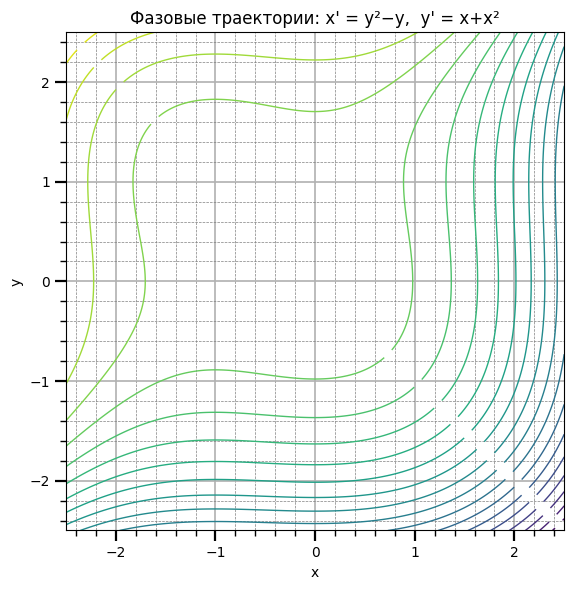

In [4]:
#3.1
# Система: x' = y^2 - y,  y' = x + x^2
# dy/dx = (x + x**2)/(y**2 - y)
# Интегрируя: ∫(y^2 - y)dy = ∫(x + x**2)dx
# => (1/3)y^3 - (1/2)y**2 - (1/2)x**2 - (1/3)x**3 = C
def F(X, Y):
    return (1/3)*Y**3 - 0.5*Y**2 - 0.5*X**2 - (1/3)*X**3  # уровни F = const — фазовые траектории

x = np.linspace(-2.5, 2.5, 400)
y = np.linspace(-2.5, 2.5, 400)
X, Y = np.meshgrid(x, y)
Z = F(X, Y)

levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 22)

fig, ax = plt.subplots(figsize=(6, 6))
cs = ax.contour(X, Y, Z, levels=levels, linewidths=1)
ax.clabel(cs, inline=1, fontsize=8, fmt='')

ax.set_title("Фазовые траектории: x' = y²−y,  y' = x+x²", fontsize=12)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal', adjustable='box')
ax.grid(which='major', linewidth=1.2)
ax.grid(which='minor', linestyle='--', color='gray', linewidth=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='major', length=8, width=1.6)
ax.tick_params(which='minor', length=4, width=1)

plt.tight_layout()
plt.show()


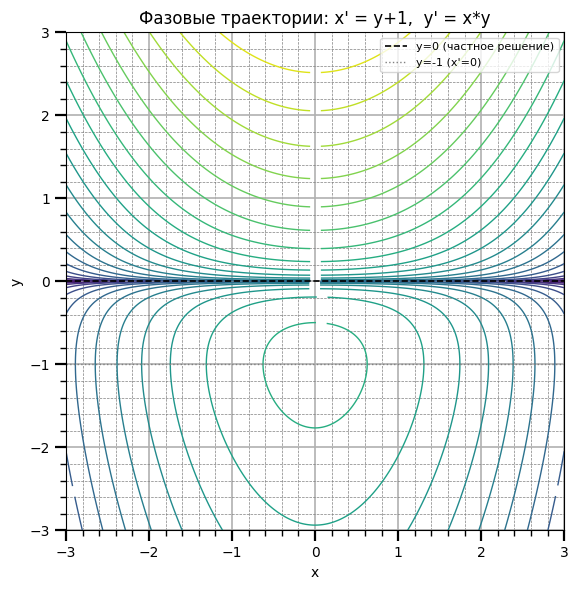

In [5]:
#3.2
def F(X, Y):
    return Y + np.log(np.abs(Y)) - 0.5*X**2

x = np.linspace(-3, 3, 600)
y = np.linspace(-3, 3, 600)
X, Y = np.meshgrid(x, y)

mask = np.isclose(Y, 0.0, atol=1e-3)
Z = F(X, Y)
Z[mask] = np.nan

finite = np.isfinite(Z)
lev = np.linspace(np.nanmin(Z[finite]), np.nanmax(Z[finite]), 22)

fig, ax = plt.subplots(figsize=(6, 6))
cs = ax.contour(X, Y, Z, levels=lev, linewidths=1)
ax.clabel(cs, inline=1, fontsize=8, fmt='')

ax.axhline(0, color='k', linewidth=1.2, linestyle='--', label='y=0 (частное решение)')
ax.axhline(-1, color='gray', linewidth=1, linestyle=':', label='y=-1 (x\'=0)')

ax.set_title("Фазовые траектории: x' = y+1,  y' = x*y", fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal', adjustable='box')
ax.grid(which='major', linewidth=1.2)
ax.grid(which='minor', linestyle='--', color='gray', linewidth=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='major', length=8, width=1.6)
ax.tick_params(which='minor', length=4, width=1)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

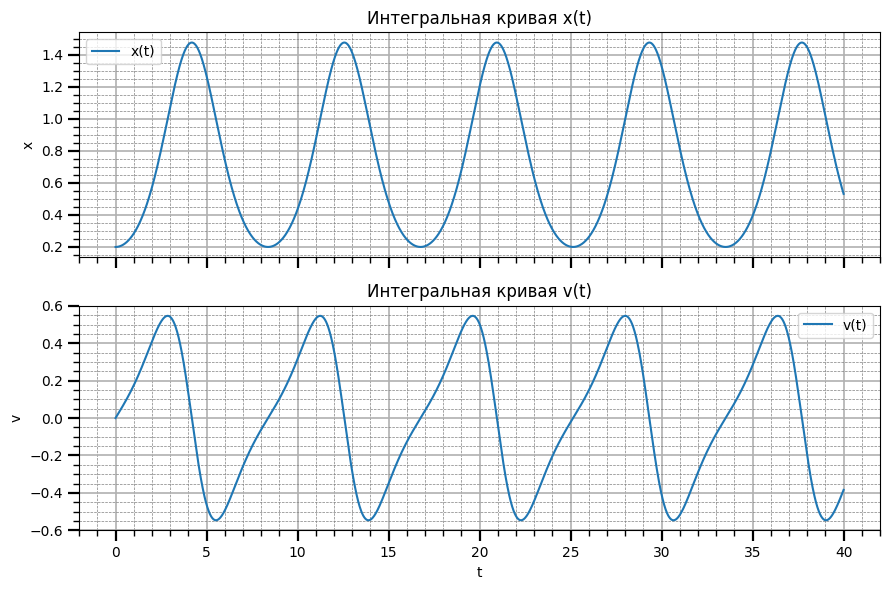

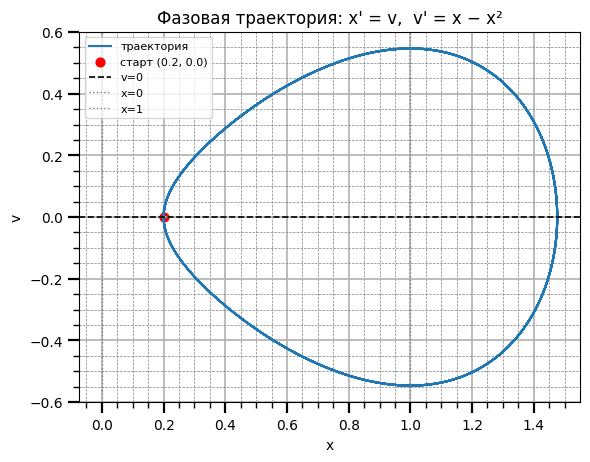

In [6]:
#4.1
def f(u, t):
    x, v = u
    return [v, x - x**2]

u0 = [0.2, 0.0]       # x(0)=0.2, v(0)=0
t = np.linspace(0, 40, 2000)

sol = odeint(f, u0, t)
x, v = sol[:, 0], sol[:, 1]

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax[0].plot(t, x, label='x(t)')
ax[1].plot(t, v, label='v(t)')

for a, ttl in zip(ax, ['Интегральная кривая x(t)', 'Интегральная кривая v(t)']):
    a.set_title(ttl, fontsize=12)
    a.grid(which='major', linewidth=1.2)
    a.grid(which='minor', linestyle='--', color='gray', linewidth=0.5)
    a.xaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.set_minor_locator(AutoMinorLocator())
    a.tick_params(which='major', length=8, width=1.6)
    a.tick_params(which='minor', length=4, width=1)
    a.legend()

ax[1].set_xlabel('t')
ax[0].set_ylabel('x')
ax[1].set_ylabel('v')
plt.tight_layout()

fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.plot(x, v, label='траектория')
ax2.scatter([u0[0]], [u0[1]], c='r', s=40, label=f'старт ({u0[0]}, {u0[1]})')

ax2.axhline(0, linewidth=1.2, linestyle='--', color='k', label='v=0')
ax2.axvline(0, linewidth=1, linestyle=':', color='gray', label='x=0')
ax2.axvline(1, linewidth=1, linestyle=':', color='gray', label='x=1')

ax2.set_title("Фазовая траектория: x' = v,  v' = x − x²", fontsize=12)
ax2.set_xlabel('x')
ax2.set_ylabel('v')
ax2.set_aspect('equal', adjustable='box')
ax2.grid(which='major', linewidth=1.2)
ax2.grid(which='minor', linestyle='--', color='gray', linewidth=0.5)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.tick_params(which='major', length=8, width=1.6)
ax2.tick_params(which='minor', length=4, width=1)
ax2.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()